# **House Price Analysis and Prediction**
Task By **[InternnCraft](linkedin.com/company/internncraft)**
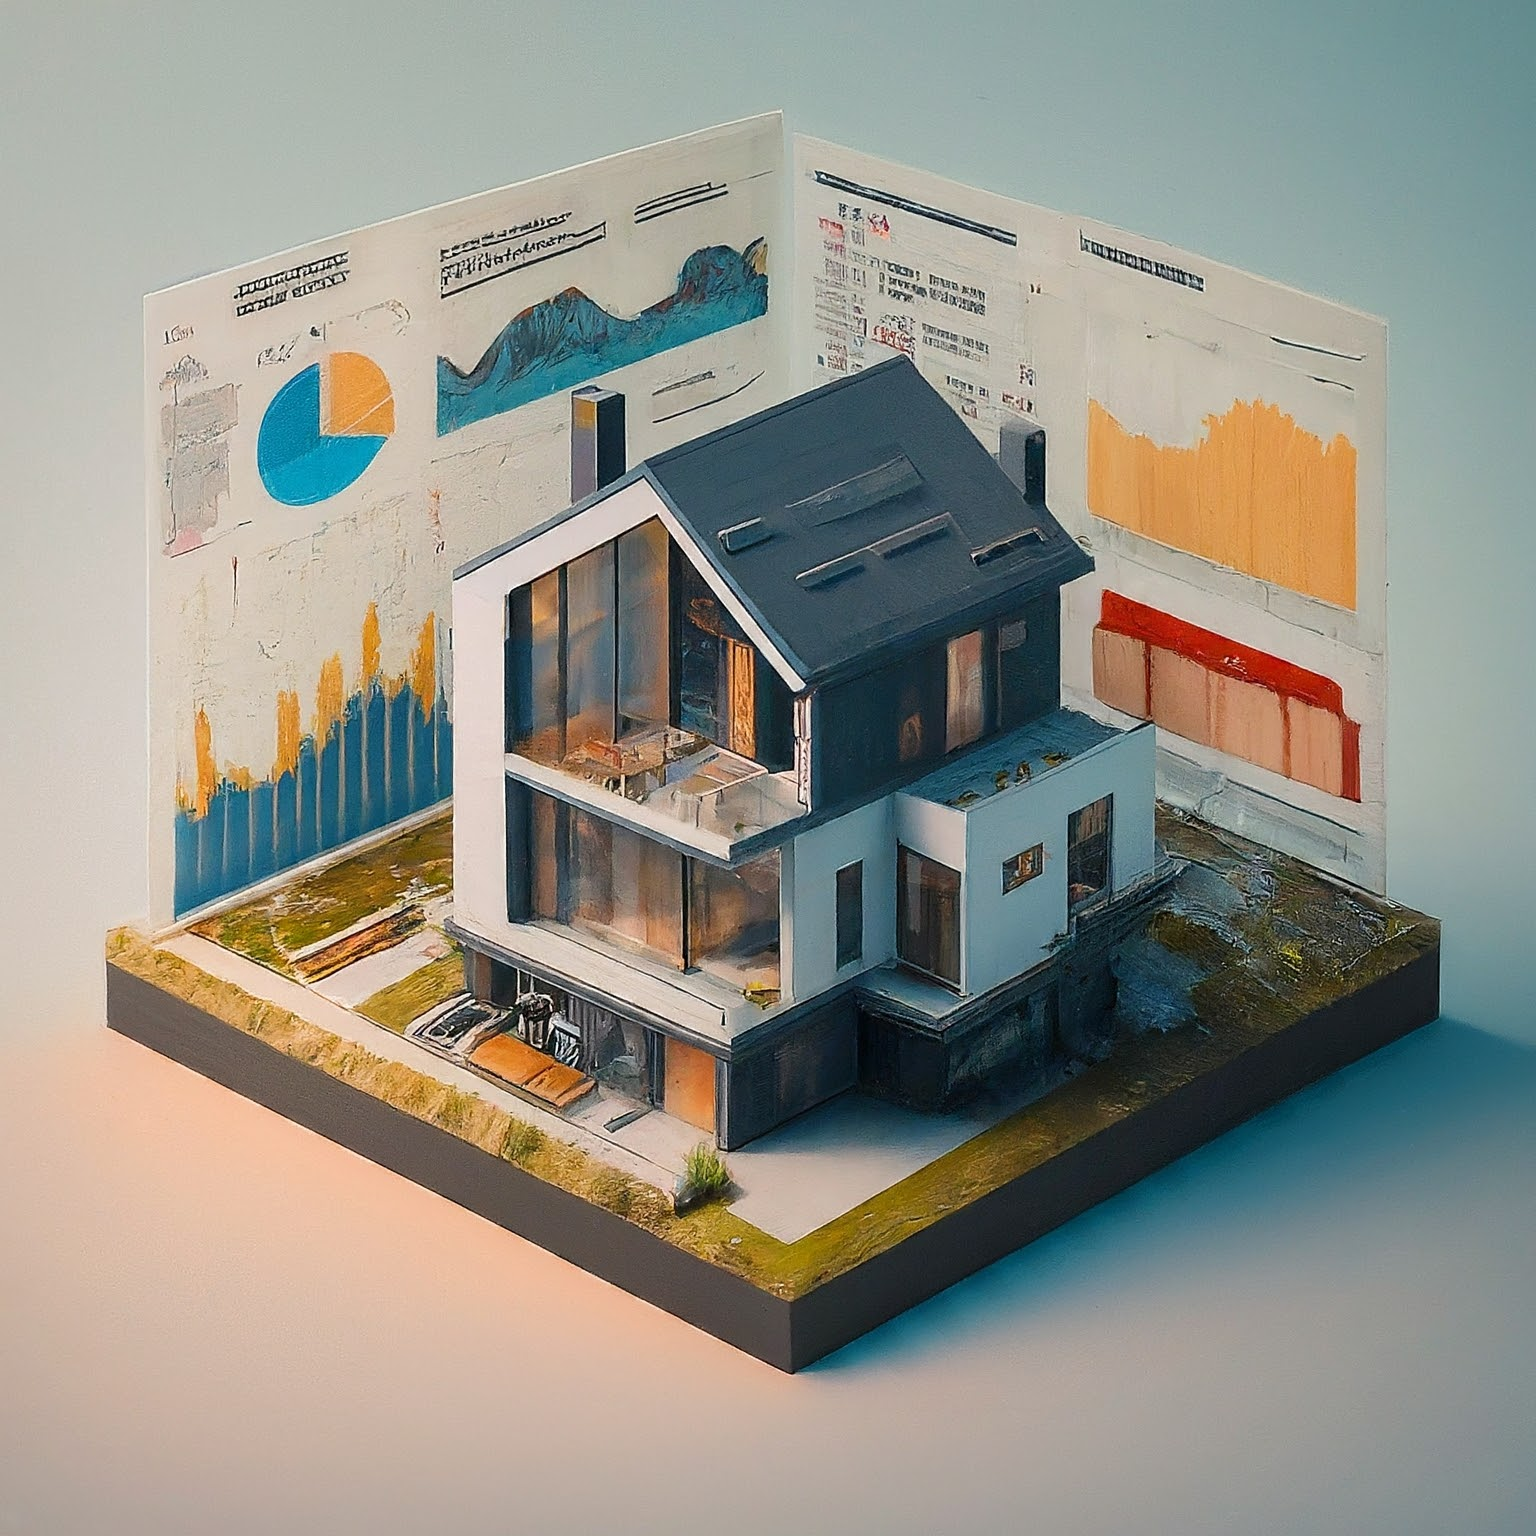

#### **Dataset Description**

This dataset includes real estate property listings with details on attributes, location, and pricing.

##### **Attributes**

1. **property_id**: Unique identifier for each property (`int64`).
2. **location_id**: Identifier for the property's location (`int64`).
3. **page_url**: URL link to property details (`object`).
4. **property_type**: Type of property (e.g., house, apartment) (`object`).
5. **price**: Price of the property (`int64`).
6. **location**: Specific location (e.g., neighborhood) (`object`).
7. **city**: City of the property (`object`).
8. **province_name**: Province where the property is located (`object`).
9. **latitude**: Geographic latitude (`float64`).
10. **longitude**: Geographic longitude (`float64`).
11. **baths**: Number of bathrooms (`int64`).
12. **area**: Total area size (e.g., Marla, Kanal) (`object`).
13. **purpose**: Listing purpose (e.g., sale, rent) (`object`).
14. **bedrooms**: Number of bedrooms (`int64`).
15. **date_added**: Date when the listing was added (`object`).
16. **agency**: Real estate agency (`object`, contains missing values).
17. **agent**: Responsible agent (`object`, contains missing values).
18. **Area Type**: Measurement type (e.g., Marla, Kanal) (`object`).
19. **Area Size**: Size of the area (`float64`).
20. **Area Category**: Area size category (e.g., 0-5 Marla) (`object`).

**Total Rows**: 168,446  
**Total Columns**: 20


#### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium
import datetime 
from scipy import stats
from scipy.stats import zscore
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import LabelEncoder
from folium.plugins import MarkerCluster
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#### **Load the Dataset and Initial Inception**

In [2]:
# Set the display option
pd.options.display.max_columns = None

df = pd.read_csv('zameen-updated.csv')

# check the 5 rows of dataset
df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla


In [3]:
# Get the number of rows and columns
df.shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 168446
Number of columns: 20


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  str    
 3   property_type  168446 non-null  str    
 4   price          168446 non-null  int64  
 5   location       168446 non-null  str    
 6   city           168446 non-null  str    
 7   province_name  168446 non-null  str    
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  str    
 12  purpose        168446 non-null  str    
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  str    
 15  agency         124375 non-null  str    
 16  agent          124374 non-null  str    
 17  Area Type      168446 non-null  str    


In [5]:
# Check the column names to identify the target variable
print(df.columns)

Index(['property_id', 'location_id', 'page_url', 'property_type', 'price',
       'location', 'city', 'province_name', 'latitude', 'longitude', 'baths',
       'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent',
       'Area Type', 'Area Size', 'Area Category'],
      dtype='str')


In [6]:
# Get data types
print(df.dtypes)

property_id        int64
location_id        int64
page_url             str
property_type        str
price              int64
location             str
city                 str
province_name        str
latitude         float64
longitude        float64
baths              int64
area                 str
purpose              str
bedrooms           int64
date_added           str
agency               str
agent                str
Area Type            str
Area Size        float64
Area Category        str
dtype: object


In [7]:
# Summary statistics for numerical columns
df.describe()
# print(df.describe())

,property_id,location_id,price,latitude,longitude,baths,bedrooms,Area Size
count,1.684460e+05,168446.000000,1.684460e+05,168446.000000,168446.000000,168446.000000,168446.000000,168446.000000
mean,1.559626e+07,4375.936395,1.776576e+07,29.859519,71.239804,2.874227,3.179422,5.892188
std,2.251207e+06,3776.561581,3.531003e+07,3.807870,3.133042,2.463400,1.971401,5.778327
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000,0.000000
25%,1.488320e+07,1058.000000,1.750000e+05,24.948536,67.130363,0.000000,2.000000,3.000000
50%,1.665851e+07,3286.000000,8.500000e+06,31.459784,73.056182,3.000000,3.000000,5.000000
75%,1.708662e+07,7220.000000,1.950000e+07,33.560887,73.259870,4.000000,4.000000,8.000000
max,1.735772e+07,14220.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000,800.000000


In [8]:
# Summary statistics for categorical columns
# print(df.describe(include=['object']))
df.describe(include=['object'])

C:\Users\AK\AppData\Local\Temp\ipykernel_1128\2988223751.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,page_url,property_type,location,city,province_name,area,purpose,date_added,agency,agent,Area Type,Area Category
count,168446,168446,168446,168446,168446,168446,168446,168446,124375,124374,168446,168446
unique,168446,7,1509,5,3,344,2,124,5761,10598,2,22
top,https://www.zameen.com/Property/g_10_g_10_2_gr...,House,DHA Defence,Karachi,Punjab,1 Kanal,For Sale,07-03-2019,Real Investment Consultants,Boez Ayub,Marla,0-5 Marla
freq,1,105468,22046,60484,70536,20061,120655,9485,794,787,137769,64501


In [9]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning)

### **Data Cleaning and Exploration**

#### **Clean the Data**

##### **a. Identify and Handle Missing Values**

In [10]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           44071
agent            44072
Area Type            0
Area Size            0
Area Category        0
dtype: int64


In [11]:
# Example of filling missing values with a placeholder
df['agency'].fillna('Unknown', inplace=True)
df['agent'].fillna('Unknown', inplace=True)

# Example of dropping rows with missing values
# df.dropna(inplace=True)

0                                              Unknown
1                                              Unknown
2                                              Unknown
3                                              Unknown
4         Muhammad Junaid Ceo Muhammad Shahid Director
                              ...                     
168441                                         Shahmir
168442                                         Shahmir
168443                                         Shahmir
168444                                         Shahmir
168445                                        Ali Raza
Name: agent, Length: 168446, dtype: str

In [12]:
# Checking Missing Value after Handling
df.isnull().sum()

property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           44071
agent            44072
Area Type            0
Area Size            0
Area Category        0
dtype: int64

##### **b. Identify and Handle Inconsistencies**

- ##### **Strip Leading/Trailing Spaces and Convert to Lowercase**
  - This ensures consistency in categorical columns by removing any extraneous spaces and making all entries lowercase, which helps in avoiding mismatches due to case sensitivity or extra spaces.

In [13]:
categorical_columns = ['page_url', 'property_type', 'location', 'city', 'province_name', 'purpose', 'agency', 'agent', 'Area Type', 'Area Category']

for col in categorical_columns:
    df[col] = df[col].str.strip().str.lower()

- ##### **Validate 'Price'**
    - Ensuring that the price is positive is crucial, as negative values or zero may be erroneous or indicative of missing data.

In [14]:
df = df[df['price'] > 0]

- ##### **Validate 'Latitude' and 'Longitude'**
  - Validating geographical coordinates to ensure they fall within the expected ranges (-90 to 90 for latitude and -180 to 180 for longitude) is important for ensuring accurate location data.

In [15]:
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]

- ##### **Validate 'Baths' and 'Bedrooms'**
  - Ensuring that the number of bathrooms and bedrooms are non-negative integers helps in maintaining data integrity.

In [16]:
df = df[df['baths'] >= 0]
df = df[df['bedrooms'] >= 0]

##### **c. Checking Duplicates**

In [17]:
# Checking for duplicate values
duplicates = df.duplicated().sum()
print("Number of Duplicates:" , duplicates)

Number of Duplicates: 0


##### **d. Outlier Detection and Handling**

- ##### **Outliers in Price vs Area Size**

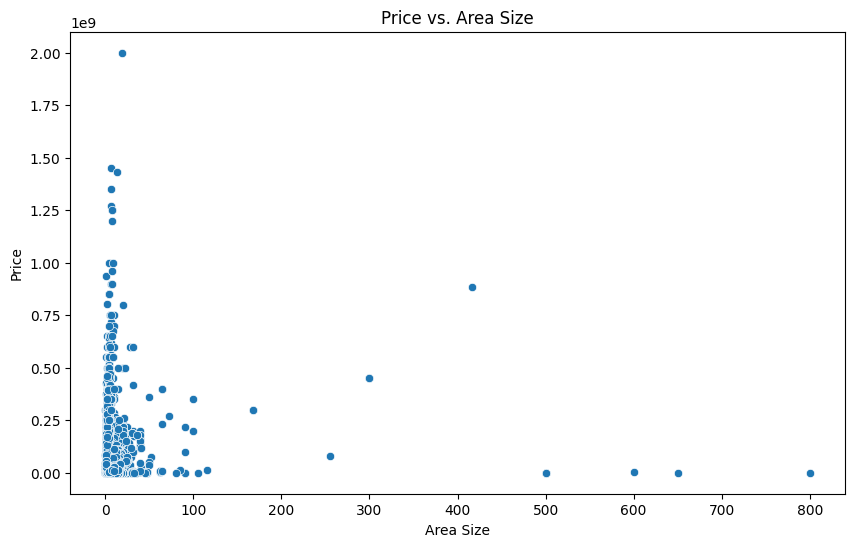

In [18]:
# Scatter plot to identify outliers in price vs. area size
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Area Size', y='price', data=df)
plt.title('Price vs. Area Size')
plt.xlabel('Area Size')
plt.ylabel('Price')
plt.show()

- ##### **Outliers in price**

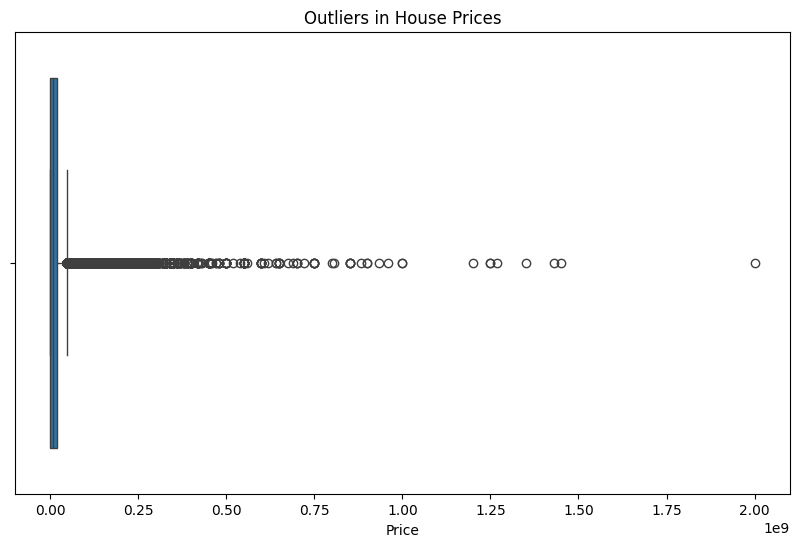

In [19]:
# Box plot to visualize outliers in price
plt.figure(figsize=(10, 6))
sns.boxplot(x='price', data=df)
plt.title('Outliers in House Prices')
plt.xlabel('Price')
plt.show()

- ##### **Outliers in Numerical Features**

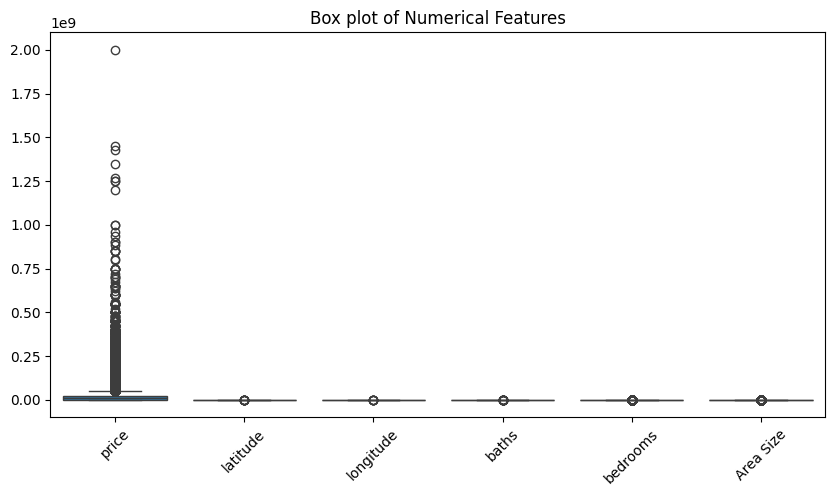

In [20]:
# Numerical columns for outlier detection
numerical_columns = ['price', 'latitude', 'longitude', 'baths', 'bedrooms', 'Area Size']

# Box plot visualization to identify outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[numerical_columns])
plt.title('Box plot of Numerical Features')
plt.xticks(rotation=45)
plt.show()

  ##### **Statistical Methods for Outlier Detection and Handling**

- ##### **IQR Method***
  - The Interquartile Range (IQR) method is another popular method for outlier detection.

In [21]:
# Calculate IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define Outlier Boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = (df[numerical_columns] < lower_bound) | (df[numerical_columns] > upper_bound)

# Count outliers for each numerical column
outliers_count = outliers.sum()
print("Number of Outliers:")
print(outliers_count)

Number of Outliers:
price        13547
latitude         0
longitude        0
baths            0
bedrooms         0
Area Size        0
dtype: int64


- ##### **Handling Outliers**

In [22]:
# Winsorize numerical columns
df['price'] = winsorize(df['price'], limits=[0.01, 0.01])
df['latitude'] = winsorize(df['latitude'], limits=[0.05, 0.05])
df['longitude'] = winsorize(df['longitude'], limits=[0.05, 0.05])
df['baths'] = winsorize(df['baths'], limits=[0.05, 0.05])
df['bedrooms'] = winsorize(df['bedrooms'], limits=[0.05, 0.05])
df['Area Size'] = winsorize(df['Area Size'], limits=[0.05, 0.05])

In [23]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'price'
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

# Define the upper and lower bounds for outlier detection
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

# Calculate the mean of 'price' and convert it to integer (int)
mean_price = int(df['price'].mean())

# Replace outliers with the mean
df.loc[df['price'] > upper_bound_price, 'price'] = mean_price
df.loc[df['price'] < lower_bound_price, 'price'] = mean_price

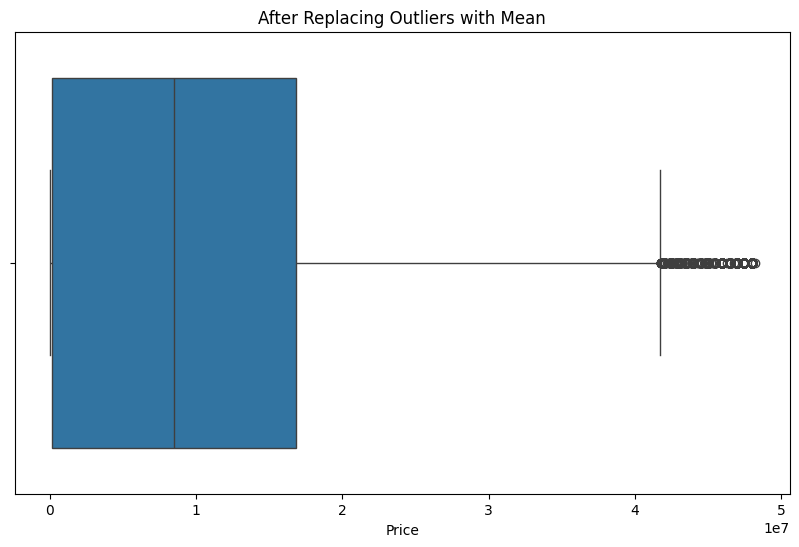

In [24]:
# Box plot to visualize outliers in price after outliers handling
plt.figure(figsize=(10, 6))
sns.boxplot(x='price', data=df)
plt.title('After Replacing Outliers with Mean')
plt.xlabel('Price')
plt.show()

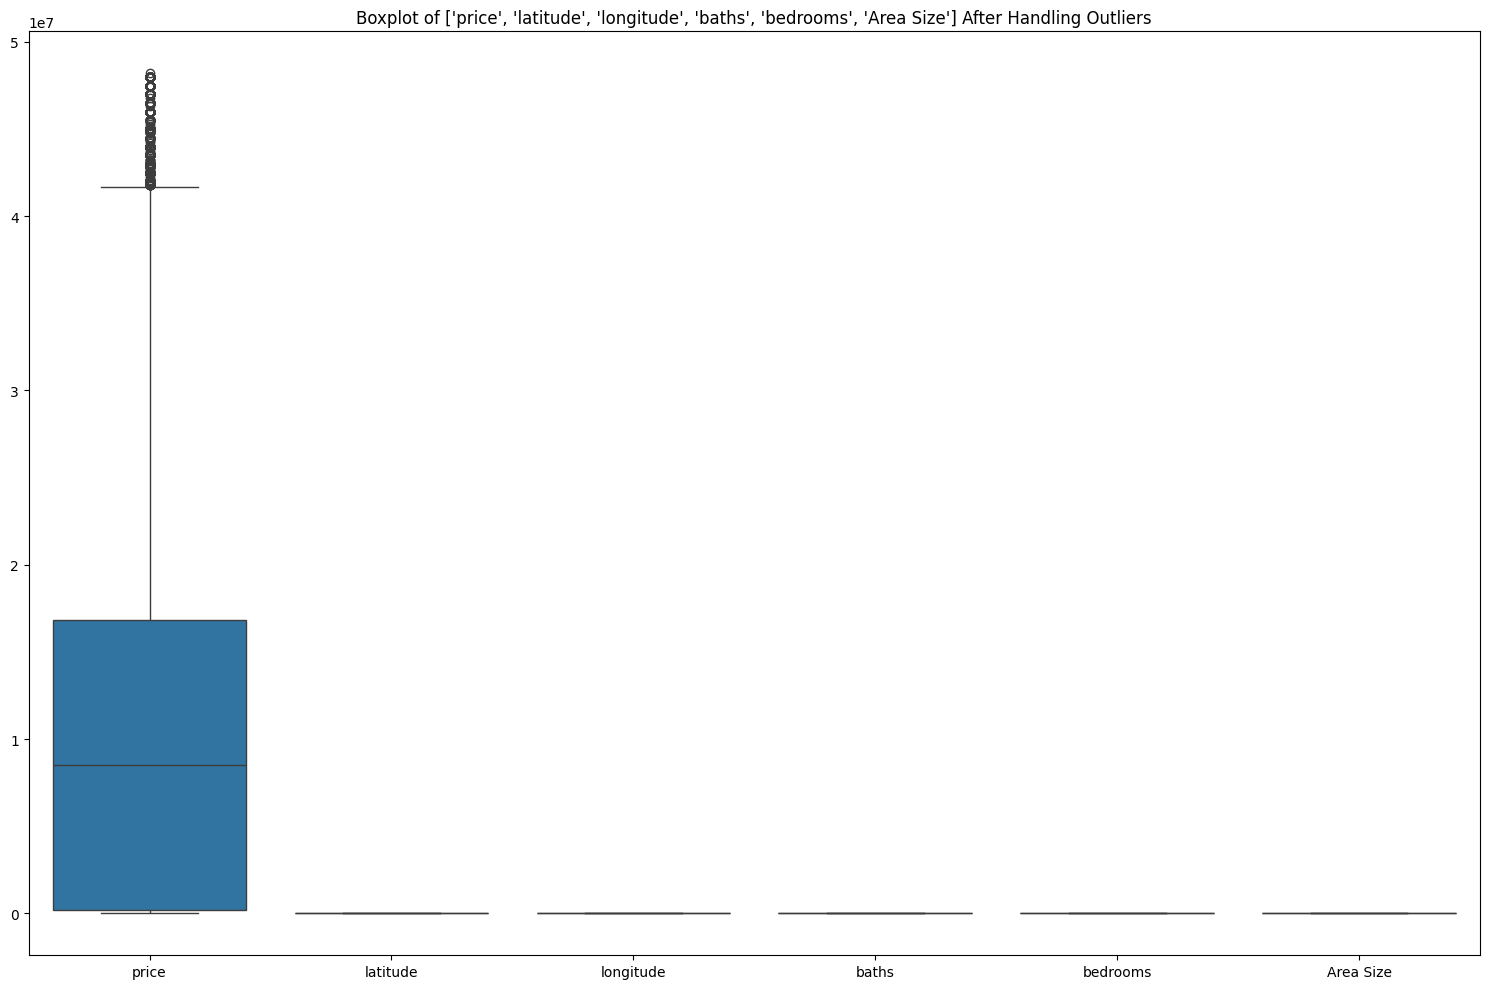

In [25]:
# Visualize numerical columns after handling outliers
plt.figure(figsize=(15, 10))
sns.boxplot(df[numerical_columns])
plt.title(f'Boxplot of {numerical_columns} After Handling Outliers')
plt.tight_layout()
plt.show()

- ##### **Outliers After Handling**

In [26]:
# Create a mask for outliers using NumPy operations
outliers_post = (df[numerical_columns] < lower_bound_price) | (df[numerical_columns] > upper_bound_price)

# Count outliers for each numerical column
outliers_count_post = outliers_post.sum()

# Print the number of outliers after handling
print("Number of Outliers After Handling:")
print(outliers_count_post)

Number of Outliers After Handling:
price        0
latitude     0
longitude    0
baths        0
bedrooms     0
Area Size    0
dtype: int64


#### **1.2. Data Exploration**

##### **a. Analyze the Distribution of House Prices**

 - ##### **Histogram and KDE Plot for Price Distribution**

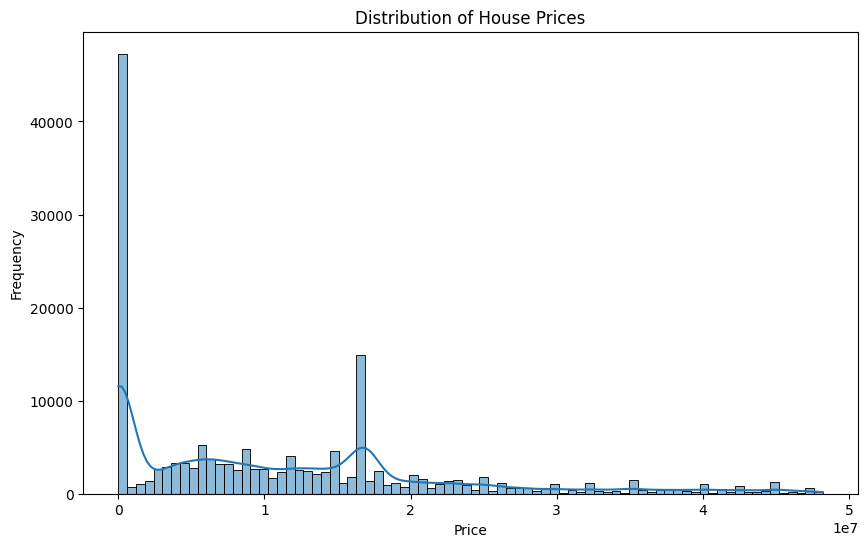

In [27]:
# Histogram and KDE Plot for Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

- ##### **Histograms & Box Plot for Numerical Features**

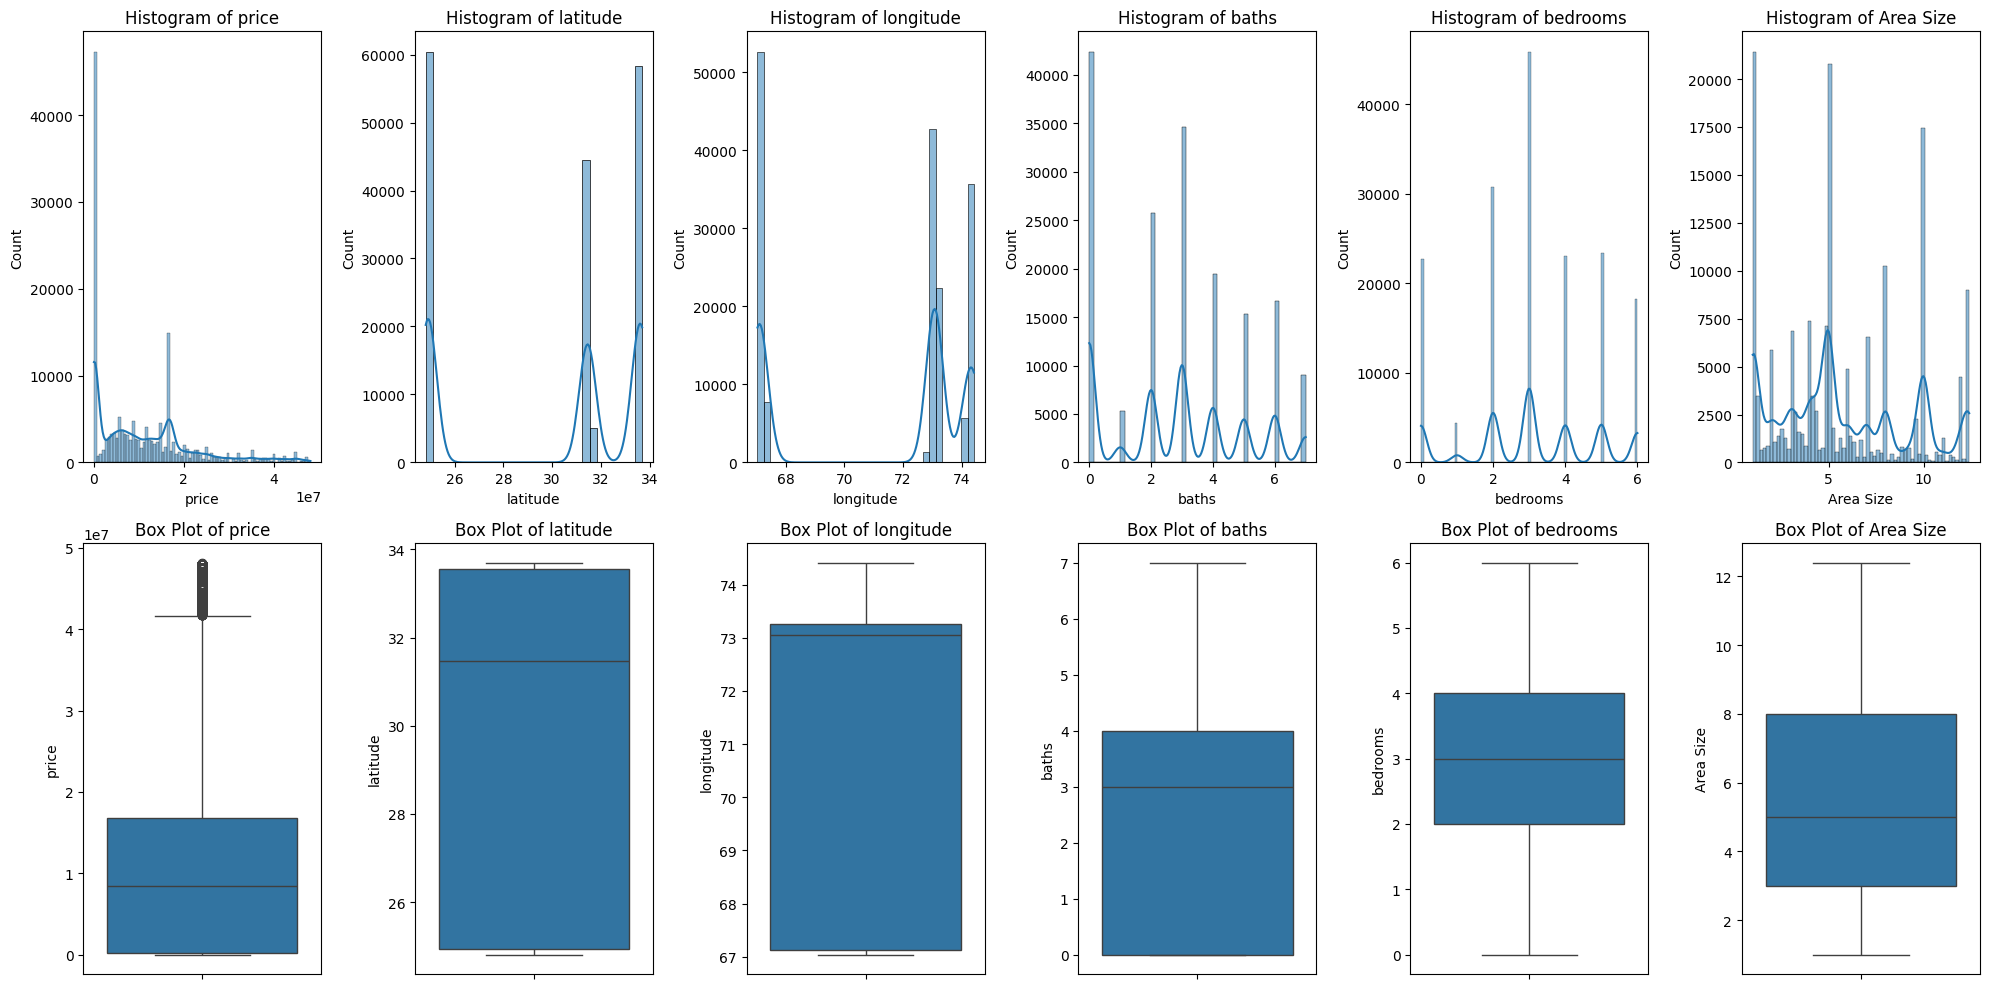

In [28]:
# Histograms and Box Plots for Numerical Features
numerical_columns = ['price', 'latitude', 'longitude', 'baths', 'bedrooms', 'Area Size']

plt.figure(figsize=(20, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, len(numerical_columns), i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    
    plt.subplot(2, len(numerical_columns), len(numerical_columns) + i)
    sns.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

- ##### **Scatter Plots to Identify Relationships Between Features and Price**

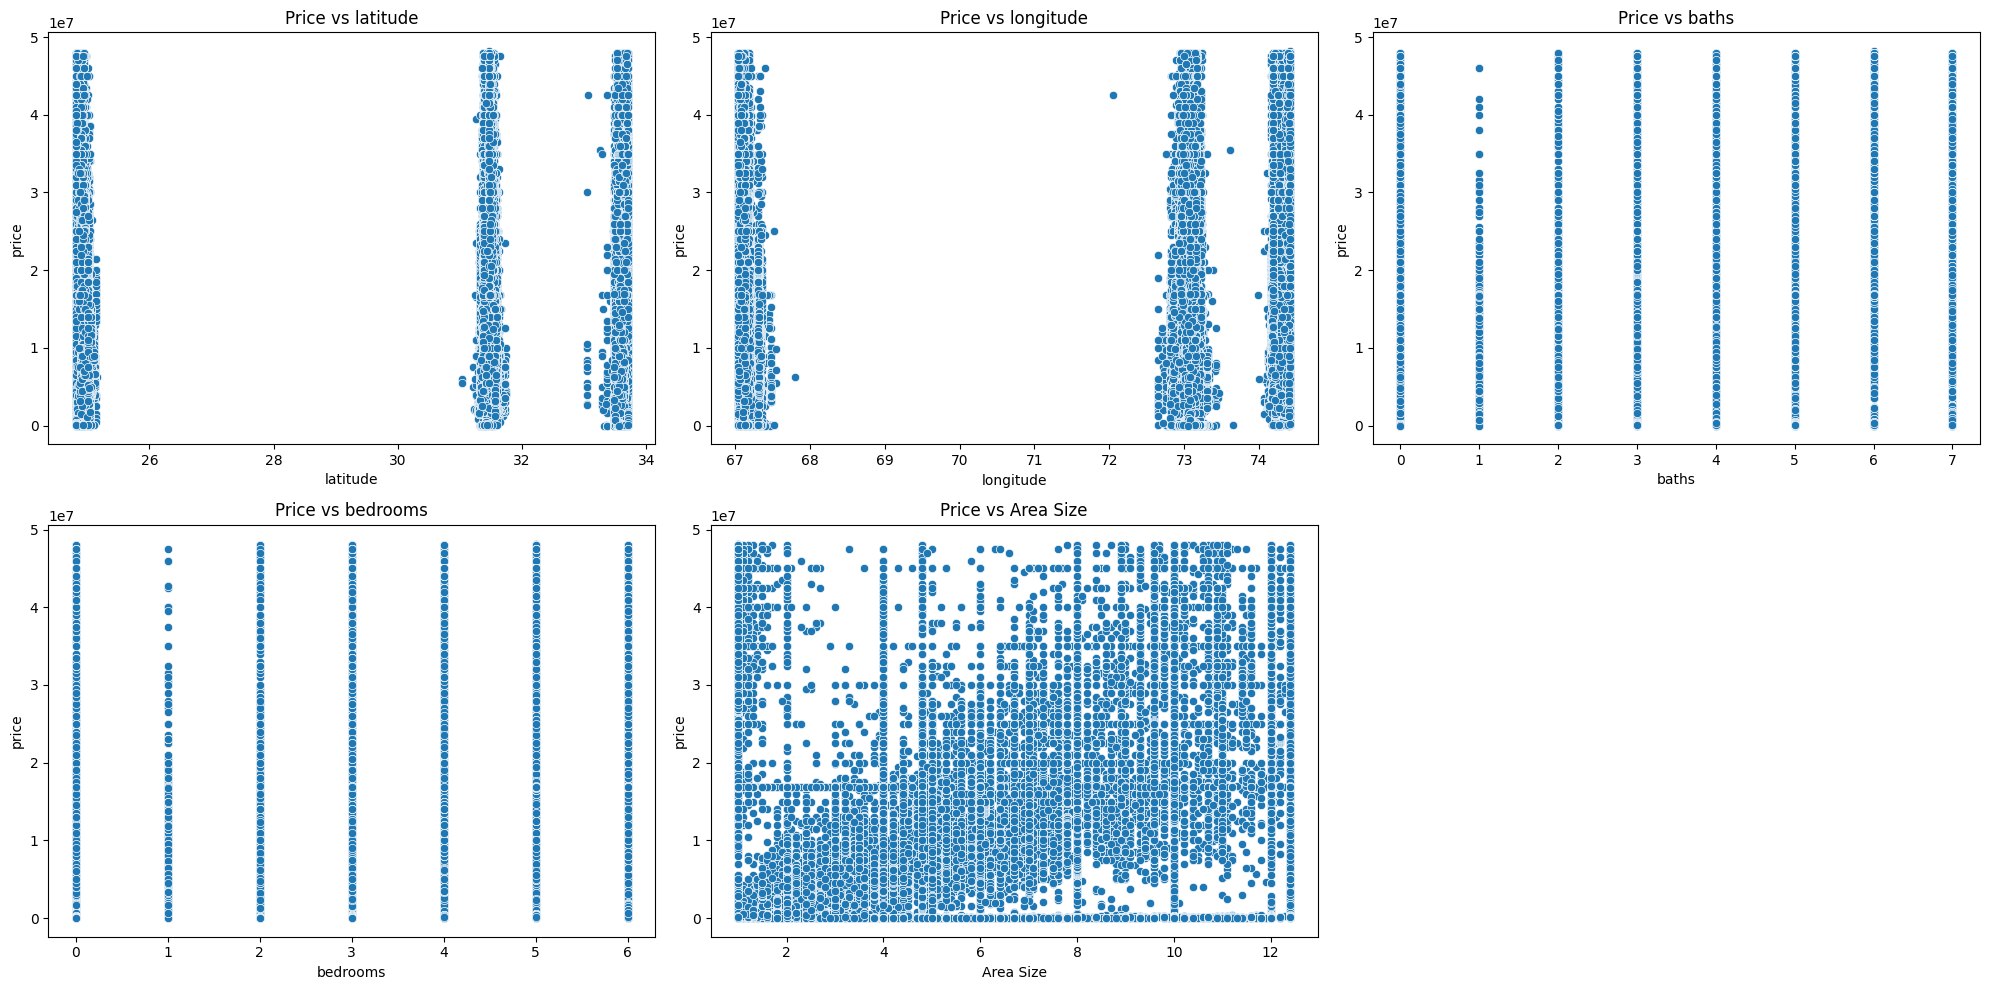

In [29]:
# Scatter Plots for Numerical Features vs. Price
plt.figure(figsize=(20, 10))
for i, col in enumerate(numerical_columns[1:], 1):  # Exclude 'price' from the loop
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[col], y=df['price'])
    plt.title(f'Price vs {col}')
plt.tight_layout()
plt.show()

- ##### **Bar Plots for Categorical Features vs. Price**

In [30]:
# Remove leading/trailing whitespace and standardize case
df['agency'] = df['agency'].str.strip().str.title()

# Handle missing values (optional)
df['agency'].fillna('Unknown', inplace=True)

0                            Unknown
1                            Unknown
2                            Unknown
3                            Unknown
4                      Easy Property
                     ...            
168441         Al Shahab Enterprises
168442         Al Shahab Enterprises
168443         Al Shahab Enterprises
168444         Al Shahab Enterprises
168445    Zpn Real Estate & Builders
Name: agency, Length: 168443, dtype: str

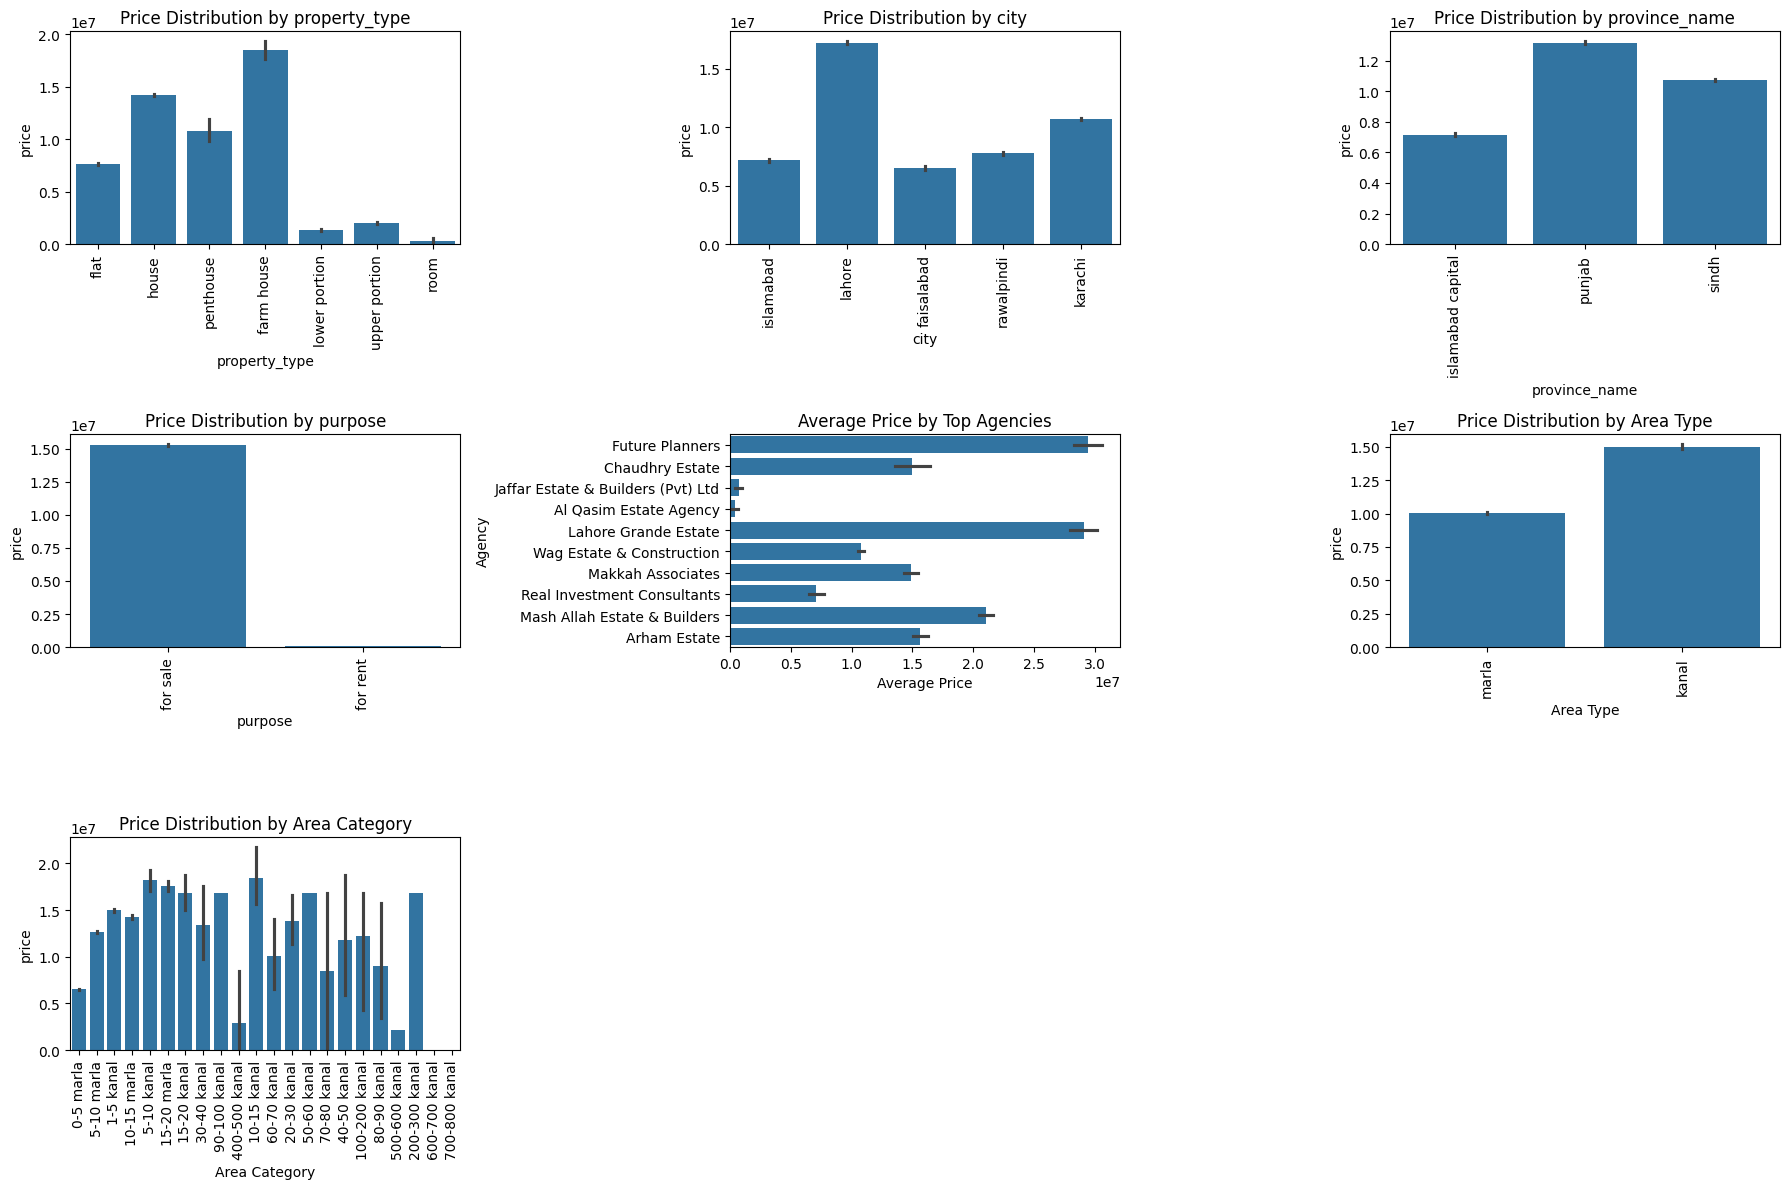

In [31]:
# Define categorical columns
categorical_columns = ['property_type', 'city', 'province_name', 'purpose', 'agency', 'Area Type', 'Area Category']

# Create bar plots for categorical features vs. price
plt.figure(figsize=(18, 12))  # Adjust figure size to accommodate all subplots

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)  # Use a 3x3 grid
    if col == 'agency':  # Special handling for 'agency'
        # Aggregate data for the top agencies
        top_agencies = df['agency'].value_counts().head(10).index
        filtered_df = df[df['agency'].isin(top_agencies)]
        sns.barplot(x='price', y='agency', data=filtered_df, estimator='mean')
        plt.title('Average Price by Top Agencies')
        plt.xlabel('Average Price')
        plt.ylabel('Agency')
    else:
        # For other categorical columns
        sns.barplot(x=df[col], y=df['price'], estimator='mean')  # Plot price distribution by categorical feature
        plt.xticks(rotation=90)  # Rotate x-axis labels for readability
        plt.title(f'Price Distribution by {col}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


- ##### **Correlation Analysis**

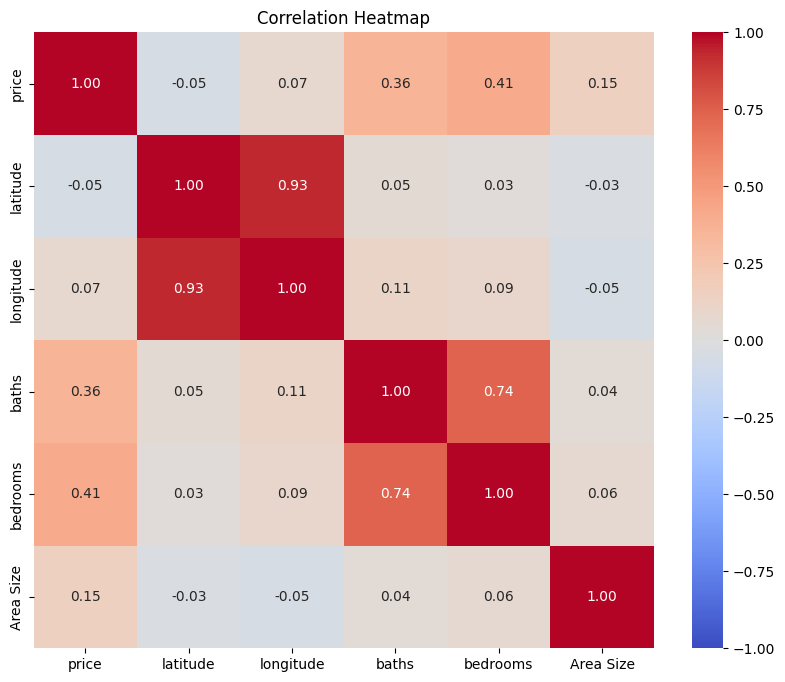

In [32]:
# Calculate correlation matrix
corr_matrix = df[numerical_columns].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

- ##### **Visualization of Geographical Data**

In [33]:
# Calculate the mean latitude and longitude
mean_lat = df['latitude'].mean()
mean_lon = df['longitude'].mean()

# Create a map centered at the mean latitude and longitude
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=6)

# Add a marker cluster to the map
marker_cluster = MarkerCluster().add_to(m)

# Add markers to the cluster
for _, row in df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Price: {row['price']}, Beds: {row['bedrooms']}, Baths: {row['baths']}"
    ).add_to(marker_cluster)

# Save the map to an HTML file
map_filename = 'house_price_map.html'
m.save(map_filename)

### **Feature Engineering**

##### **Create New Features**  

- ##### **Age of the House**

In [34]:
from datetime import datetime

# Extract the year from 'date_added' and calculate the age
current_year = datetime.now().year
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['house_age'] = current_year - df['date_added'].dt.year // 365

# Handle any possible errors due to 'date_added' conversion by filling NaN with median age
df['house_age'].fillna(df['house_age'].median(), inplace=True)

0         2021
1         2021
2         2021
3         2021
4         2021
          ... 
168441    2021
168442    2021
168443    2021
168444    2021
168445    2021
Name: house_age, Length: 168443, dtype: int32

- ##### **Convert area to Numeric**

In [35]:
# Function to convert area measurements to square feet
def convert_area(area):
    if isinstance(area, str):
        area = area.replace(',', '')  # Remove commas from the string
        if 'Marla' in area:
            value = float(area.split()[0])
            return value * 272.25
        elif 'Kanal' in area:
            value = float(area.split()[0])
            return value * 20 * 272.25
        elif 'Square Feet' in area:
            value = float(area.split()[0])
            return value
    return area  

# Apply the conversion function to the 'area' column
df['area'] = df['area'].apply(convert_area)

In [36]:
# Convert non-string values to strings
df['area'] = df['area'].astype(str)

# Remove non-numeric characters and convert 'area' to float
df['area'] = df['area'].str.replace(' Marla', '', regex=False).str.replace(',', '').astype(float)

# Verify the conversion
print(df[['area']].head())

      area
0   1089.0
1   1524.6
2   2178.0
3  10890.0
4   2178.0


- ##### **Calculate Price per Square Foot**

In [37]:
# Calculate price per square foot
df['price_per_sqft'] = df['price'] / df['area']

- ##### **Number of Bedrooms Per Floor**

In [38]:
# Create a new feature: number of bedrooms per floor
df['bedrooms_per_floor'] = df['bedrooms'] / df['area']

# Handle any possible errors due to division by zero or NaN values
df['bedrooms_per_floor'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['bedrooms_per_floor'].fillna(df['bedrooms_per_floor'].median(), inplace=True)

0         0.001837
1         0.001968
2         0.002296
3         0.000367
4         0.001377
            ...   
168441    0.002296
168442    0.001377
168443    0.002296
168444    0.001413
168445    0.001172
Name: bedrooms_per_floor, Length: 168443, dtype: float64

- ##### **Bathrooms Per Bedroom**

In [39]:
# Create a new feature: number of bathrooms per bedroom
df['baths_per_bedroom'] = df['baths'] / df['bedrooms']

# Handle any possible errors due to division by zero or NaN values
df['baths_per_bedroom'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['baths_per_bedroom'].fillna(df['baths_per_bedroom'].median(), inplace=True)

0         1.0
1         1.0
2         1.2
3         1.0
4         1.0
         ... 
168441    0.0
168442    0.0
168443    0.0
168444    0.0
168445    1.0
Name: baths_per_bedroom, Length: 168443, dtype: float64

- ##### **Displaying New Features**

In [40]:
# Check if the new features are created
print(df.columns)

Index(['property_id', 'location_id', 'page_url', 'property_type', 'price',
       'location', 'city', 'province_name', 'latitude', 'longitude', 'baths',
       'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent',
       'Area Type', 'Area Size', 'Area Category', 'house_age',
       'price_per_sqft', 'bedrooms_per_floor', 'baths_per_bedroom'],
      dtype='str')


In [41]:
# Display new features
print(df[['house_age', 'bedrooms_per_floor', 'baths_per_bedroom']].head())

   house_age  bedrooms_per_floor  baths_per_bedroom
0       2021            0.001837                1.0
1       2021            0.001968                1.0
2       2021            0.002296                1.2
3       2021            0.000367                1.0
4       2021            0.001377                1.0


- ##### **Encode Categorical Features**

- ##### **One-Hot Encoding**
    - Convert categorical variables into a format suitable for machine learning models using one-hot encoding.


In [42]:
# List of categorical columns to encode
categorical_columns = [
    'property_type', 'location', 'city', 
    'province_name', 'purpose', 'agency', 
    'agent', 'Area Type', 'Area Category'
]

# Perform one-hot encoding on the categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [43]:
# Display the first few rows of the encoded dataset
print(df_encoded.head())

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [44]:
# Save the dataset with new features
df.to_csv('new_features_dataset.csv', index=False)

##### **Outlier Analysis**

- ##### **Calculate Z-scores for 'price'**

In [45]:
# Calculate Z-scores for 'price'
df['price_zscore'] = zscore(df['price'])

# Define a threshold for identifying outliers (e.g., z-score greater than 3 or less than -3)
outliers_high = df[df['price_zscore'] > 3]
outliers_low = df[df['price_zscore'] < -3]

# Display the number of outliers
print("Number of High Price Outliers:", len(outliers_high))
print("Number of Low Price Outliers:", len(outliers_low))

Number of High Price Outliers: 2528
Number of Low Price Outliers: 0


- ##### **Investigate Outliers**
    - ##### **Print Information About High Price Outliers***

In [46]:
print("High Price Outliers:")
print(outliers_high[['property_id', 'price', 'location', 'area', 'bedrooms', 'baths', 'house_age']])

High Price Outliers:
        property_id     price            location        area  bedrooms  \
11          1586658  48000000  diplomatic enclave    2123.550         2   
23          2682075  47000000  diplomatic enclave    2286.900         3   
67          2311887  45000000              askari    5445.000         5   
91          3463063  47500000         eme society    5445.000         0   
171         2478189  45000000         bath island    2423.025         3   
...             ...       ...                 ...         ...       ...   
168247     17354062  45000000         bahria town    5445.000         6   
168302     17353521  45000000       super highway  217800.000         0   
168357     17355045  47500000         dha defence    5445.000         5   
168375     17355743  45000000         dha defence    5445.000         5   
168382     17356163  45000000         dha defence    5445.000         5   

        baths  house_age  
11          2       2021  
23          2       2021

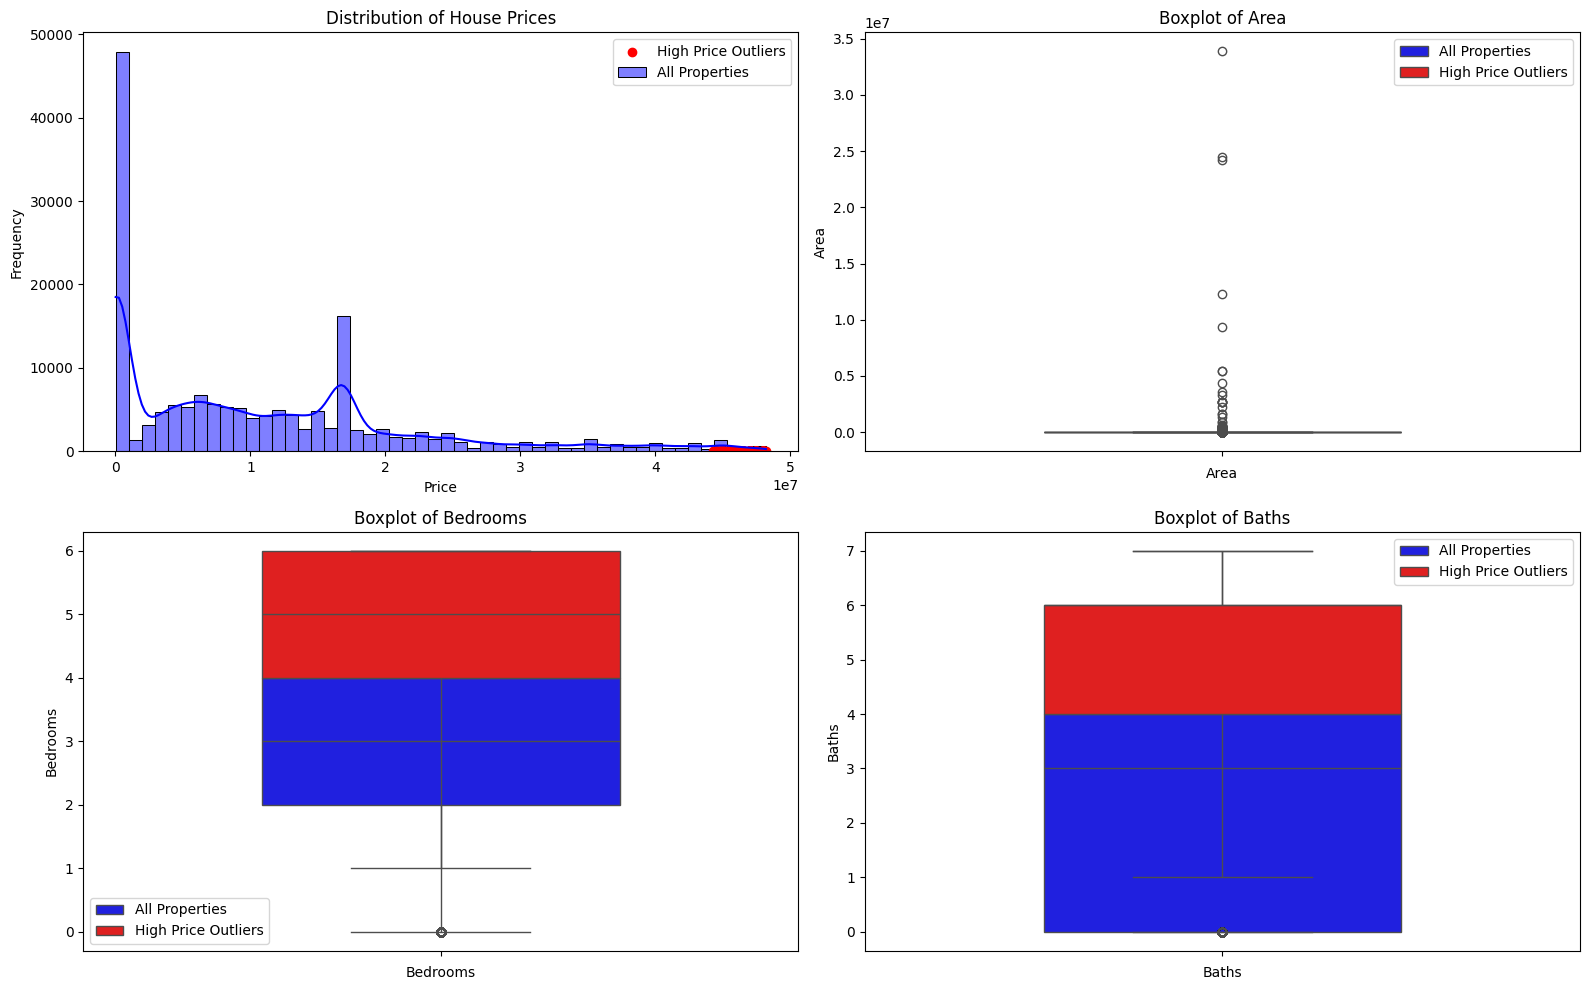

In [47]:
# Set up the matplotlib figure
plt.figure(figsize=(16, 10))

# Plotting all visualizations in a single figure
plot_titles = ['Distribution of House Prices', 'Boxplot of Area', 'Boxplot of Bedrooms', 'Boxplot of Baths']
plot_data = [
    (df['price'], outliers_high['price'], 'Price', 'blue', 'red', 'Frequency'),
    (df['area'], outliers_high['area'], 'Area', 'blue', 'red', 'Area'),
    (df['bedrooms'], outliers_high['bedrooms'], 'Bedrooms', 'blue', 'red', 'Bedrooms'),
    (df['baths'], outliers_high['baths'], 'Baths', 'blue', 'red', 'Baths')
]

# Create subplots
for i, (data_all, data_outliers, feature_name, color_all, color_outliers, y_label) in enumerate(plot_data):
    plt.subplot(2, 2, i+1)
    if feature_name == 'Price':
        sns.histplot(data_all, kde=True, bins=50, color=color_all, label='All Properties')
        plt.scatter(data_outliers, [0] * len(data_outliers), color=color_outliers, label='High Price Outliers')
    else:
        sns.boxplot(data=data_all, color=color_all, width=0.5, label='All Properties')
        sns.boxplot(data=data_outliers, color=color_outliers, width=0.5, label='High Price Outliers')
    
    plt.title(f'{plot_titles[i]}')
    plt.xlabel(feature_name)
    plt.ylabel(y_label)
    plt.legend()

plt.tight_layout()
plt.show()

- ##### **Compare Summary Statistics**

In [48]:
# Summary statistics for key features
summary_stats_all = df[['area', 'bedrooms', 'baths', 'house_age']].describe()
summary_stats_outliers = outliers_high[['area', 'bedrooms', 'baths', 'house_age']].describe()

print("Summary Statistics for All Properties:")
print(summary_stats_all)

print("\nSummary Statistics for High Price Outliers:")
print(summary_stats_outliers)

Summary Statistics for All Properties:
               area       bedrooms          baths  house_age
count  1.684430e+05  168443.000000  168443.000000   168443.0
mean   3.934694e+03       3.100224       2.835707     2021.0
std    1.273968e+05       1.777040       2.177108        0.0
min    0.000000e+00       0.000000       0.000000     2021.0
25%    1.306800e+03       2.000000       0.000000     2021.0
50%    1.932975e+03       3.000000       3.000000     2021.0
75%    3.267000e+03       4.000000       4.000000     2021.0
max    3.387988e+07       6.000000       7.000000     2021.0

Summary Statistics for High Price Outliers:
                area     bedrooms        baths  house_age
count    2528.000000  2528.000000  2528.000000     2528.0
mean     5213.027492     4.641218     4.712025     2021.0
std      6598.377489     1.577391     2.366528        0.0
min        27.225000     0.000000     0.000000     2021.0
25%      3865.950000     4.000000     4.000000     2021.0
50%      5445.00000

- ##### **Analyze Feature Contributions**

In [49]:
# Correlation matrix for outliers
corr_outliers_high = outliers_high[['price', 'house_age', 'bedrooms', 'area', 'baths', 'price_per_sqft']].corr()

print("Correlation Matrix for High Price Outliers:")
print(corr_outliers_high)

Correlation Matrix for High Price Outliers:
                   price  house_age  bedrooms      area     baths  \
price           1.000000        NaN  0.077540 -0.014538  0.081803   
house_age            NaN        NaN       NaN       NaN       NaN   
bedrooms        0.077540        NaN  1.000000 -0.083116  0.639957   
area           -0.014538        NaN -0.083116  1.000000 -0.021345   
baths           0.081803        NaN  0.639957 -0.021345  1.000000   
price_per_sqft -0.018731        NaN -0.022498 -0.074567 -0.022862   

                price_per_sqft  
price                -0.018731  
house_age                  NaN  
bedrooms             -0.022498  
area                 -0.074567  
baths                -0.022862  
price_per_sqft        1.000000  


- ##### **Investigate Specific Cases**

In [50]:
# Manual inspection of extreme outliers
extreme_outliers_high = outliers_high.sort_values(by='price', ascending=False).head(10)
print("Extreme High Price Outliers:")
print(extreme_outliers_high[['price', 'house_age', 'bedrooms', 'area', 'baths', 'price_per_sqft']])

Extreme High Price Outliers:
           price  house_age  bedrooms      area  baths  price_per_sqft
67593   48200000       2021         5  5445.000      6     8852.157943
11      48000000       2021         2  2123.550      2    22603.658967
919     48000000       2021         6  8167.500      7     5876.951331
517     48000000       2021         3  2804.175      5    17117.333975
79934   48000000       2021         5  5445.000      7     8815.426997
79192   48000000       2021         5  5445.000      7     8815.426997
39430   48000000       2021         4  4356.000      4    11019.283747
161896  48000000       2021         6  5445.000      7     8815.426997
167513  48000000       2021         5  5445.000      6     8815.426997
161877  48000000       2021         0  3865.950      0    12416.094362


#### **Predictive Modeling**

In [51]:
# Define features and target
features = ['area', 'bedrooms', 'baths', 'house_age', 'latitude', 'longitude']
target = 'price'

X = df[features]
y = df[target]

# Drop non-numeric columns
# df = df.drop(columns=['page_url'])

- ##### **Spliting the Data**

In [52]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### **Linear Regression**

In [53]:
# Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.86, 1808453.06, 525153.22, 0. ,-2144701.21, 2548022.79]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['area','bedrooms','baths','house_age','latitude','longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.136e+08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [54]:
# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("Mean Absolute Error:", mae_lr)
print("Mean Squared Error:", mse_lr)
print("R-squared:", r2_lr)

Linear Regression Performance:
Mean Absolute Error: 7124822.039398647
Mean Squared Error: 92482556269026.17
R-squared: 0.24622447543329973


##### **Random forest** 

In [55]:
# Train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [56]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("Mean Absolute Error:", mae_rf)
print("Mean Squared Error:", mse_rf)
print("R-squared:", r2_rf)

Random Forest Performance:
Mean Absolute Error: 4125138.894459355
Mean Squared Error: 49993450477856.29
R-squared: 0.5925303010740159


##### **Gradient Boosting**

In [57]:
# Train the Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [58]:
# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance:")
print("Mean Absolute Error:", mae_gb)
print("Mean Squared Error:", mse_gb)
print("R-squared:", r2_gb)

Gradient Boosting Performance:
Mean Absolute Error: 5580709.004915759
Mean Squared Error: 62483769829101.02
R-squared: 0.49072843269136934


- ##### **Comparison of Actual vs Predicted House Prices**

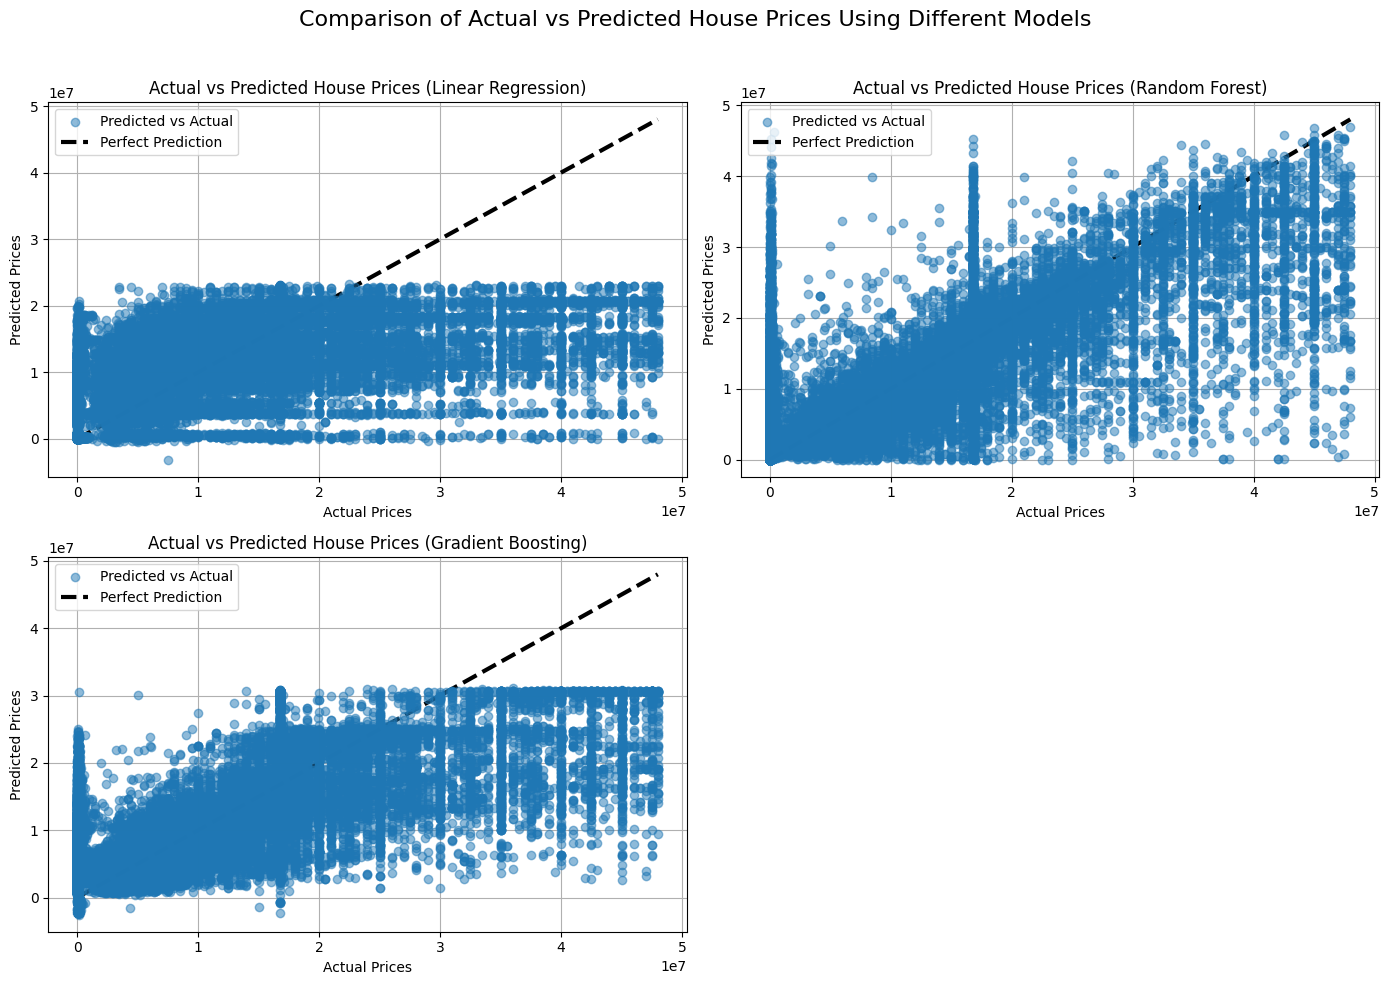

In [59]:
# Function to create scatter plot for a given model
def plot_predicted_vs_actual(ax, y_test, y_pred, model_name):
    ax.scatter(y_test, y_pred, alpha=0.5, label='Predicted vs Actual', zorder=3)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, label='Perfect Prediction', zorder=2)
    ax.set_xlabel('Actual Prices')
    ax.set_ylabel('Predicted Prices')
    ax.set_title(f'Actual vs Predicted House Prices ({model_name})')
    ax.legend()
    ax.grid(True, zorder=1)

# Set up the figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Plot for Linear Regression
plot_predicted_vs_actual(axs[0, 0], y_test, y_pred_lr, 'Linear Regression')

# Plot for Random Forest
plot_predicted_vs_actual(axs[0, 1], y_test, y_pred_rf, 'Random Forest')

# Plot for Gradient Boosting
plot_predicted_vs_actual(axs[1, 0], y_test, y_pred_gb, 'Gradient Boosting')

# Hide the empty subplot in the bottom right corner
axs[1, 1].axis('off')

# Add a main title for the whole figure
fig.suptitle('Comparison of Actual vs Predicted House Prices Using Different Models', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the main title
plt.show()

- #### **Future Prediction**

In [60]:
# Define the function to predict prices
def predict_prices(hypothetical_data, lr_model, rf_model, gb_model):
    # Create a DataFrame with hypothetical scenarios
    df_hypothetical = pd.DataFrame(hypothetical_data)
    
    # Use trained models to predict prices for hypothetical scenarios
    predicted_prices_lr = lr_model.predict(df_hypothetical)
    predicted_prices_rf = rf_model.predict(df_hypothetical)
    predicted_prices_gb = gb_model.predict(df_hypothetical)
    
    return predicted_prices_lr, predicted_prices_rf, predicted_prices_gb

In [61]:
# Define the hypothetical scenarios (adjust as per your data structure)
hypothetical_data = {
    'area': [3000, 1800, 2200],  # in square feet
    'bedrooms': [5, 3, 4],
    'baths': [4, 2, 3],
    'house_age': [12, 7, 9],
    'latitude': [32.7767, 34.0522, 35.6895],
    'longitude': [96.7970, 118.2437, 139.6917]
}

# Call the function with the hypothetical data and trained models
predicted_prices_lr, predicted_prices_rf, predicted_prices_gb = predict_prices(hypothetical_data, lr_model, rf_model, gb_model)

In [62]:
# Print the predicted prices for each model
print("Predicted Prices for Hypothetical Scenarios (Linear Regression):")
print(predicted_prices_lr)

print("\nPredicted Prices for Hypothetical Scenarios (Random Forest):")
print(predicted_prices_rf)

print("\nPredicted Prices for Hypothetical Scenarios (Gradient Boosting):")
print(predicted_prices_gb)

Predicted Prices for Hypothetical Scenarios (Linear Regression):
[7.38702044e+07 1.21113076e+08 1.74585499e+08]

Predicted Prices for Hypothetical Scenarios (Random Forest):
[20070637.96296296  8772213.75        9679427.5       ]

Predicted Prices for Hypothetical Scenarios (Gradient Boosting):
[23293446.1253494   8092705.67750613 18076704.82932083]


In [63]:
# Create a DataFrame with hypothetical scenarios
df_hypothetical = pd.DataFrame(hypothetical_data)

# Use trained models to predict prices for hypothetical scenarios
predicted_prices_lr = lr_model.predict(df_hypothetical)
predicted_prices_rf = rf_model.predict(df_hypothetical)
predicted_prices_gb = gb_model.predict(df_hypothetical)

# Combine predictions into a DataFrame for easier plotting
predictions = pd.DataFrame({
    'Scenario': ['Scenario 1', 'Scenario 2', 'Scenario 3'],
    'Linear Regression': predicted_prices_lr,
    'Random Forest': predicted_prices_rf,
    'Gradient Boosting': predicted_prices_gb
})

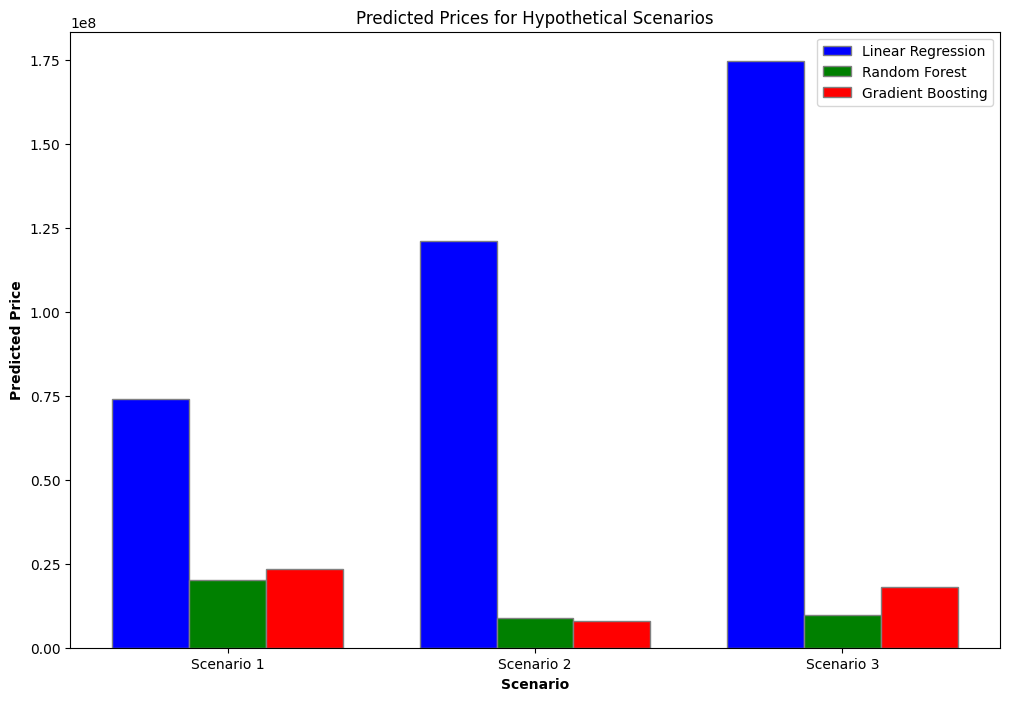

In [64]:
# Set the plot size and bar width
plt.figure(figsize=(12, 8))
bar_width = 0.25

# Set the positions of the bars on the x-axis
r1 = np.arange(len(predictions['Scenario']))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Create the bars for each model
plt.bar(r1, predictions['Linear Regression'], color='blue', width=bar_width, edgecolor='grey', label='Linear Regression')
plt.bar(r2, predictions['Random Forest'], color='green', width=bar_width, edgecolor='grey', label='Random Forest')
plt.bar(r3, predictions['Gradient Boosting'], color='red', width=bar_width, edgecolor='grey', label='Gradient Boosting')

# Add labels and title
plt.xlabel('Scenario', fontweight='bold')
plt.ylabel('Predicted Price', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(predictions['Scenario']))], predictions['Scenario'])
plt.title('Predicted Prices for Hypothetical Scenarios')

# Add legend
plt.legend()

# Show the plot
plt.show()

---